#Splitting Data Set

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df_transactions = pd.read_csv('/content/df_transactions.csv')
df_kyc = pd.read_csv('/content/df_kyc.csv')
df_labels = pd.read_csv('/content/df_label.csv')

## Splitting the Dataset into Trusted and Untrusted

In [ ]:
# Merging the transactions and labesl.
df_merged = pd.merge(df_transactions, df_labels, on=["Customer_ID", "Month"], how="inner")

# Exclude salary transactions
df_merged = df_merged[df_merged["Transaction_Type"] != "Salary"]

# Aggregate Monthly Transaction Sums
df_monthly_sum = df_merged.groupby(["Customer_ID", "Month"]).agg(
    {"Transaction_Value": lambda x: x.abs().sum()}  # Sum of absolute transaction values
).reset_index()

# Step 2: Merge the aggregated monthly sums back to the original data otherwise I had lost the features.
df_merged = pd.merge(df_merged, df_monthly_sum, on=["Customer_ID", "Month"], suffixes=("", "_Monthly_Sum"))

df_merged = pd.merge(df_merged, df_kyc, on="Customer_ID", how="inner")

# Step 3: Split Trusted and Untrusted Data
# Trusted Data: Monthly sum exceeds 9000 OR SAR is 1 (reliable labels)
trusted_data = df_merged[
    (df_merged["Transaction_Value_Monthly_Sum"] > 9000)  # Threshold exceeded
    | (df_merged["SAR"] == 1)  # Labeled as suspicious
]

# Untrusted Data: Monthly sum ≤ 9000 and SAR is 0 (unreliable labels)
untrusted_data = df_merged[
    (df_merged["Transaction_Value_Monthly_Sum"] <= 9000)  # Below threshold
    & (df_merged["SAR"] == 0)  # Not flagged and unreliable
]


In [ ]:
trusted_data.head()

,Customer_ID,Customer_ID_Counterparty,Transaction_Value,Transaction_Type,Month,SAR,Transaction_Value_Monthly_Sum,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
0,143,NaN,-221,Wire,Jan,0,13892,59,Female,True,False,True,False
5,414,NaN,5,Wire,Jan,0,9107,69,Male,True,False,False,False
7,916,NaN,-1373,Wire,Jan,0,13609,62,Male,False,False,False,False
10,123,NaN,-1992,Wire,Jan,0,10672,53,Male,True,False,False,True
11,896,NaN,-1055,Wire,Jan,0,9488,76,Male,True,False,True,True


In [ ]:
untrusted_data.head()

,Customer_ID,Customer_ID_Counterparty,Transaction_Value,Transaction_Type,Month,SAR,Transaction_Value_Monthly_Sum,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
1,758,NaN,13,Wire,Jan,0,5981,67,Female,True,False,True,False
2,485,NaN,25,Wire,Jan,0,5986,78,Male,False,False,True,True
3,238,NaN,-456,Wire,Jan,0,1795,55,Female,False,False,False,False
4,858,NaN,-4,Wire,Jan,0,3362,77,Female,False,False,False,False
6,888,NaN,-148,Wire,Jan,0,3769,18,Female,True,False,True,False


In [ ]:
# Checking if all SAR are 0.
untrusted_data['SAR'].value_counts()

,count
SAR,
0,117370


In [ ]:
# Remove the Transaction_Value_Monthly_Sum column
trusted_data = trusted_data.drop(columns=["Transaction_Value_Monthly_Sum"])
untrusted_data = untrusted_data.drop(columns=["Transaction_Value_Monthly_Sum"])

In [ ]:
trusted_data.to_csv('trusted_data.csv', index=False)
untrusted_data.to_csv('untrusted_data.csv', index=False)

In [ ]:
trusted_data.columns

Index(['Customer_ID', 'Customer_ID_Counterparty', 'Transaction_Value',
       'Transaction_Type', 'Month', 'SAR', 'Age', 'Sex', 'High_Risk_Country',
       'Vulnerable_Area', 'Intention_International_Payments',
       'Intention_Cash_Deposits'],
      dtype='object')

In [ ]:
untrusted_data.columns

Index(['Customer_ID', 'Customer_ID_Counterparty', 'Transaction_Value',
       'Transaction_Type', 'Month', 'SAR', 'Age', 'Sex', 'High_Risk_Country',
       'Vulnerable_Area', 'Intention_International_Payments',
       'Intention_Cash_Deposits'],
      dtype='object')

## EDA

```
# This is formatted as code
```



In [ ]:
trusted_data.head()

,Customer_ID,Customer_ID_Counterparty,Transaction_Value,Transaction_Type,Month,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
0,143,NaN,-221,Wire,Jan,0,59,Female,True,False,True,False
5,414,NaN,5,Wire,Jan,0,69,Male,True,False,False,False
7,916,NaN,-1373,Wire,Jan,0,62,Male,False,False,False,False
10,123,NaN,-1992,Wire,Jan,0,53,Male,True,False,False,True
11,896,NaN,-1055,Wire,Jan,0,76,Male,True,False,True,True


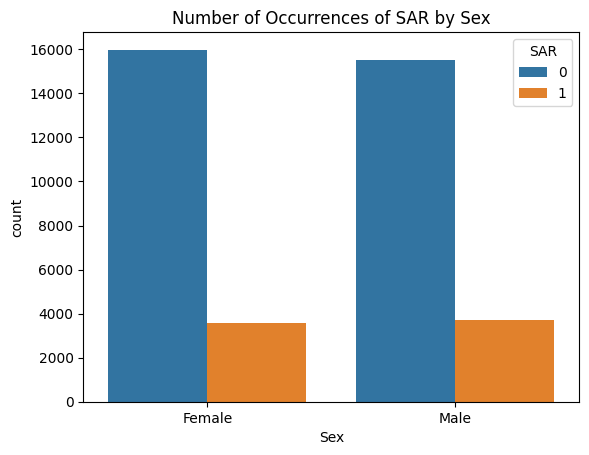

In [ ]:
sns.countplot(x='Sex', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Sex')
plt.show()

Conclusion : Sex might not strongly correlate with suspicious *activity*

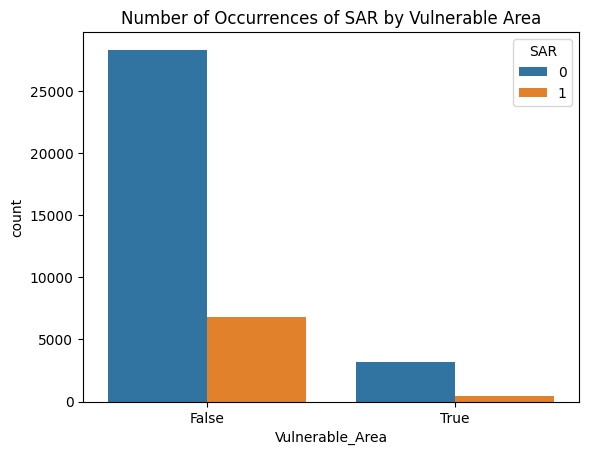

In [ ]:
sns.countplot(x='Vulnerable_Area', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

This predicts the SAR have been identified from Non Vulnerable Areas as well. There are far fewer SARs in vulnerable areas, both in absolute terms and relative to non-vulnerable areas.


**Conclusion** : The "vulnerable area" might not strongly correlate with suspicious activity

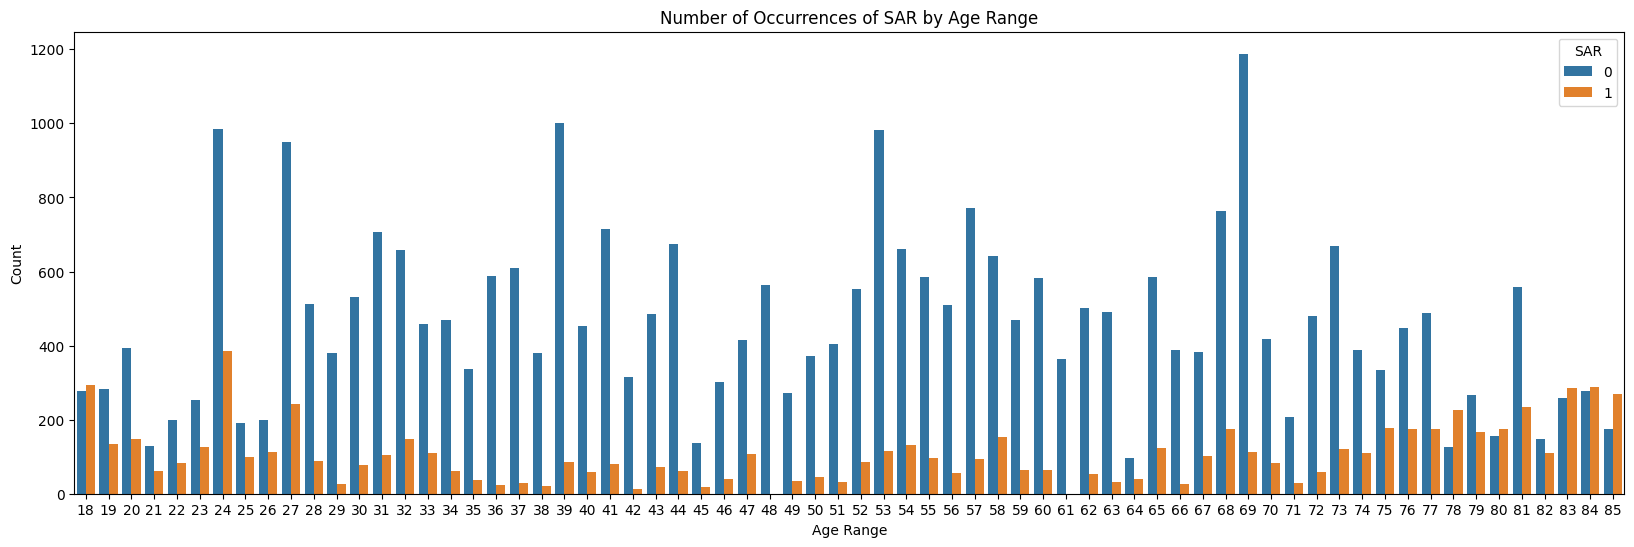

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Age', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.show()

Specific age ranges (e.g., around 23–25, 40–42, and 65–70) show relatively higher counts of SAR = 1 compared to other age groups.

Younger individuals may show higher activity overall, with a small percentage flagged as suspicious.
Older individuals might have a smaller sample size but higher relative SAR counts.

In [ ]:
# Calculate SAR count by age group
sar_counts_by_age = trusted_data.groupby(["Age", "SAR"]).size().unstack(fill_value=0)
print(sar_counts_by_age)
# Add a new column for percentage of SAR = 1
sar_counts_by_age["SAR_1_Percentage"] = (sar_counts_by_age[1] / (sar_counts_by_age[0] + sar_counts_by_age[1])) * 100

# Display the result
print(sar_counts_by_age[["SAR_1_Percentage"]])


SAR    0    1
Age          
18   277  294
19   284  134
20   393  148
21   130   61
22   199   83
..   ...  ...
81   557  235
82   148  110
83   258  285
84   278  287
85   175  269

[68 rows x 2 columns]
SAR  SAR_1_Percentage
Age                  
18          51.488616
19          32.057416
20          27.356747
21          31.937173
22          29.432624
..                ...
81          29.671717
82          42.635659
83          52.486188
84          50.796460
85          60.585586

[68 rows x 1 columns]


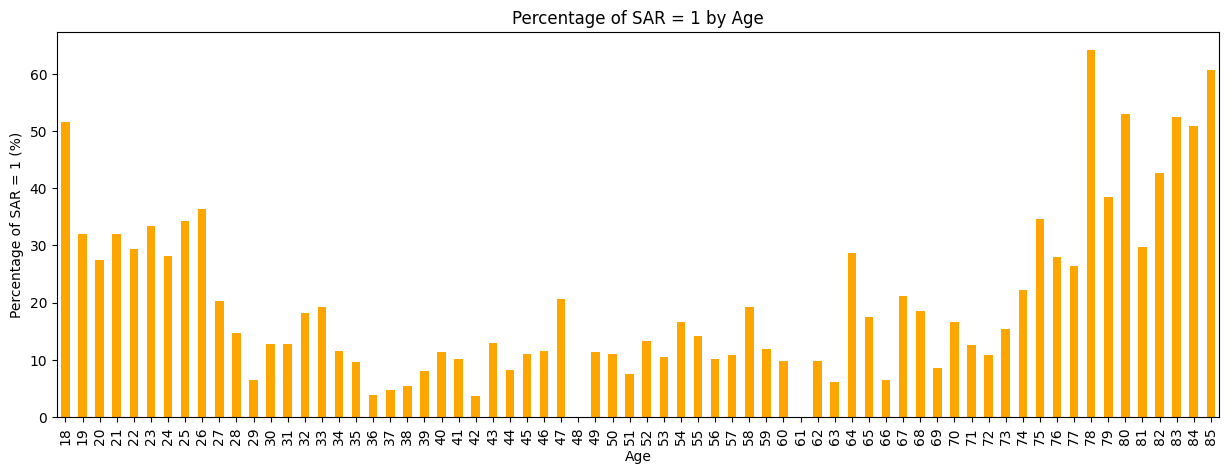

In [ ]:
import matplotlib.pyplot as plt

# Plot the percentage of SAR = 1 by age
sar_counts_by_age["SAR_1_Percentage"].plot(kind="bar", figsize=(15, 5), color="orange")
plt.title("Percentage of SAR = 1 by Age")
plt.xlabel("Age")
plt.ylabel("Percentage of SAR = 1 (%)")
plt.show()


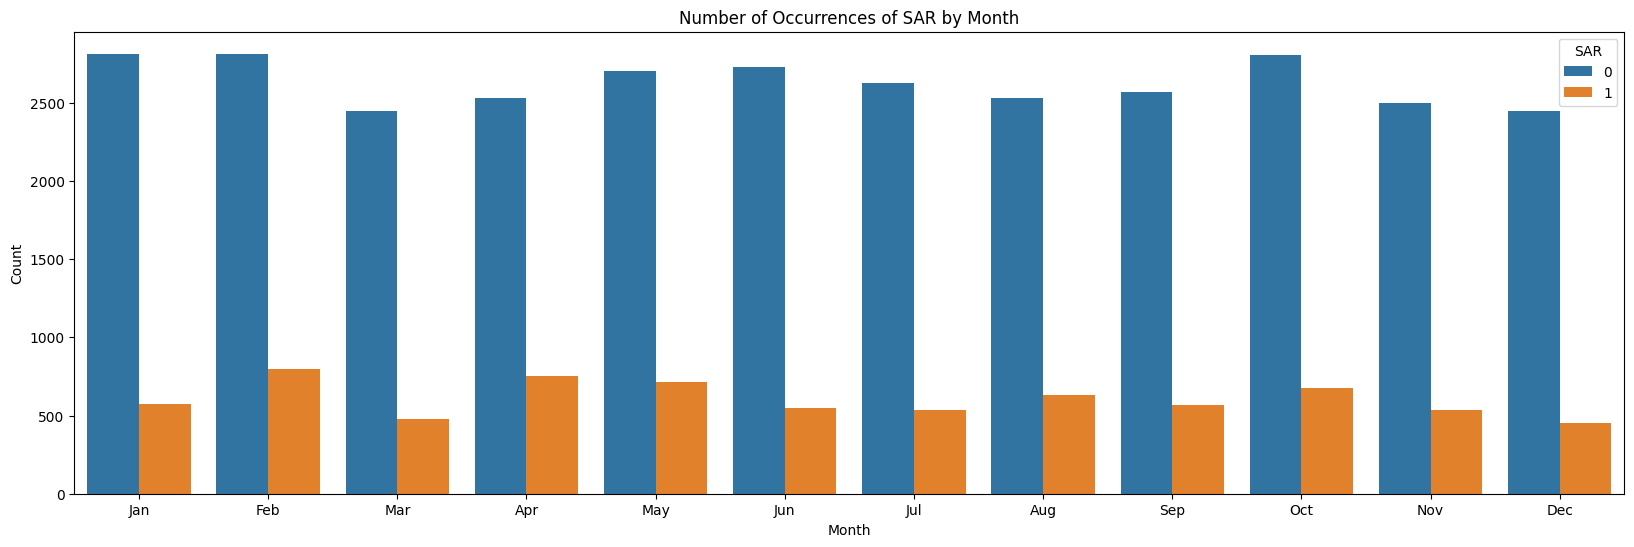

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(x='Month', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

## Feature Engineering

In [ ]:
## TODO Corelation Matrix

### Dropping columns

In [ ]:
trusted_data = trusted_data.drop(columns=["Month", "Customer_ID", "Customer_ID_Counterparty"])
trusted_data.head()

,Transaction_Value,Transaction_Type,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
0,-221,Wire,0,59,Female,True,False,True,False
5,5,Wire,0,69,Male,True,False,False,False
7,-1373,Wire,0,62,Male,False,False,False,False
10,-1992,Wire,0,53,Male,True,False,False,True
11,-1055,Wire,0,76,Male,True,False,True,True


### Onhot encoding on Transaction_Type

In [ ]:
# Perform one-hot encoding on the 'Transaction_Type' column
trusted_data = pd.get_dummies(trusted_data, columns=['Transaction_Type'], prefix='Transaction')

# Display the resulting DataFrame
print(trusted_data.head())


    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0                -221    0   59  Female               True            False   
5                   5    0   69    Male               True            False   
7               -1373    0   62    Male              False            False   
10              -1992    0   53    Male               True            False   
11              -1055    0   76    Male               True            False   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                               True                    False   
5                              False                    False   
7                              False                    False   
10                             False                     True   
11                              True                     True   

    Transaction_Cash  Transaction_International  Transaction_Wire  
0              False                      False              True 

### Categorizing age group and onehot encoding the Age

In [ ]:
# Define age bins and labels
bins = [0, 25, 45, 65, 100]  # Specify age ranges
labels = ['young', 'lower_middle', 'upper_middle', 'old']  # Corresponding labels

# Create a new column 'Age_Group' with the categorized data
trusted_data['Age_Group'] = pd.cut(trusted_data['Age'], bins=bins, labels=labels, right=False)

# Display the resulting DataFrame
print(trusted_data[['Age', 'Age_Group']].head())
trusted_data.head()

    Age     Age_Group
0    59  upper_middle
5    69           old
7    62  upper_middle
10   53  upper_middle
11   76           old


,Transaction_Value,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits,Transaction_Cash,Transaction_International,Transaction_Wire,Age_Group
0,-221,0,59,Female,True,False,True,False,False,False,True,upper_middle
5,5,0,69,Male,True,False,False,False,False,False,True,old
7,-1373,0,62,Male,False,False,False,False,False,False,True,upper_middle
10,-1992,0,53,Male,True,False,False,True,False,False,True,upper_middle
11,-1055,0,76,Male,True,False,True,True,False,False,True,old


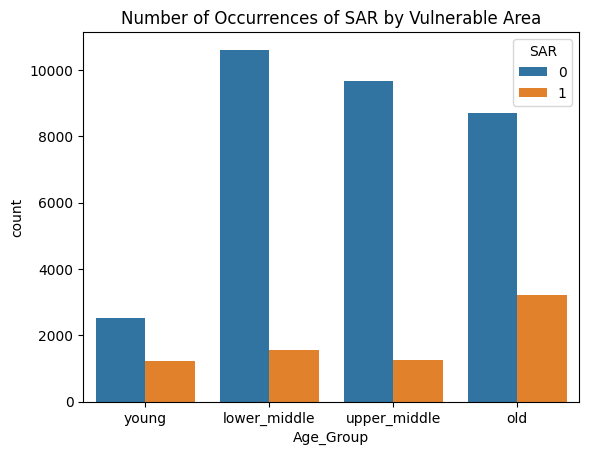

In [ ]:
sns.countplot(x='Age_Group', hue='SAR', data=trusted_data)
plt.title('Number of Occurrences of SAR by Vulnerable Area')
plt.show()

In [ ]:
# Perform one-hot encoding on the 'Transaction_Type' column
trusted_data = pd.get_dummies(trusted_data, columns=['Age_Group'], prefix='Age_Is')

# Display the resulting DataFrame
print(trusted_data.head())

    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0                -221    0   59  Female               True            False   
5                   5    0   69    Male               True            False   
7               -1373    0   62    Male              False            False   
10              -1992    0   53    Male               True            False   
11              -1055    0   76    Male               True            False   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                               True                    False   
5                              False                    False   
7                              False                    False   
10                             False                     True   
11                              True                     True   

    Transaction_Cash  Transaction_International  Transaction_Wire  \
0              False                      False              True

### Making all True and False to 1 and 0

In [ ]:
# Convert all boolean values in the DataFrame to integers (1 for True, 0 for False)
trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)

# Display the updated DataFrame
print(trusted_data.head())

<ipython-input-27-18099d53cc9d>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  trusted_data = trusted_data.applymap(lambda x: int(x) if isinstance(x, bool) else x)


    Transaction_Value  SAR  Age     Sex  High_Risk_Country  Vulnerable_Area  \
0                -221    0   59  Female                  1                0   
5                   5    0   69    Male                  1                0   
7               -1373    0   62    Male                  0                0   
10              -1992    0   53    Male                  1                0   
11              -1055    0   76    Male                  1                0   

    Intention_International_Payments  Intention_Cash_Deposits  \
0                                  1                        0   
5                                  0                        0   
7                                  0                        0   
10                                 0                        1   
11                                 1                        1   

    Transaction_Cash  Transaction_International  Transaction_Wire  \
0                  0                          0                 1

In [ ]:
trusted_data['SAR'].value_counts()

,count
SAR,
0,31512
1,7264


In [ ]:
from os import times_result
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Sex' column
trusted_data['Sex'] = label_encoder.fit_transform(trusted_data['Sex'])

# Display the unique values in the 'Sex' column after encoding
print(trusted_data['Sex'].unique())
trusted_data.head()

[0 1]


,Transaction_Value,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits,Transaction_Cash,Transaction_International,Transaction_Wire,Age_Is_young,Age_Is_lower_middle,Age_Is_upper_middle,Age_Is_old
0,-221,0,59,0,1,0,1,0,0,0,1,0,0,1,0
5,5,0,69,1,1,0,0,0,0,0,1,0,0,0,1
7,-1373,0,62,1,0,0,0,0,0,0,1,0,0,1,0
10,-1992,0,53,1,1,0,0,1,0,0,1,0,0,1,0
11,-1055,0,76,1,1,0,1,1,0,0,1,0,0,0,1


## Feature Scaling

#Sample Balancing the data

In [ ]:
trusted_data.to_csv('trusted_data_pre_train.csv', index=False)

In [ ]:
trusted_data.corr()

,Transaction_Value,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits,Transaction_Cash,Transaction_International,Transaction_Wire,Age_Is_young,Age_Is_lower_middle,Age_Is_upper_middle,Age_Is_old
Transaction_Value,1.000000,0.008684,-0.003665,-0.001092,-0.003120,-0.012550,-0.002633,-0.001530,0.107452,0.120256,-0.163412,0.007506,-0.000035,-0.010013,0.004988
SAR,0.008684,1.000000,0.076684,0.012605,0.016721,-0.054199,-0.040632,-0.027596,0.022517,0.037933,-0.044193,0.118300,-0.104016,-0.115671,0.141548
Age,-0.003665,0.076684,1.000000,0.014609,0.067129,-0.001018,0.103598,0.072602,0.000850,0.007670,-0.006543,-0.508328,-0.585791,0.117658,0.800049
Sex,-0.001092,0.012605,0.014609,1.000000,0.041441,-0.053949,0.034134,0.093442,0.000567,0.006016,-0.005067,-0.072949,-0.006414,0.084159,-0.028859
High_Risk_Country,-0.003120,0.016721,0.067129,0.041441,1.000000,-0.066232,0.064709,0.073372,-0.002515,-0.006842,0.006972,-0.083409,0.000379,0.006448,0.046792
Vulnerable_Area,-0.012550,-0.054199,-0.001018,-0.053949,-0.066232,1.000000,-0.046391,-0.077527,-0.004686,-0.011634,0.012119,0.007598,-0.009407,0.004135,0.000556
Intention_International_Payments,-0.002633,-0.040632,0.103598,0.034134,0.064709,-0.046391,1.000000,0.091728,-0.006951,-0.001394,0.005581,-0.066932,-0.062577,0.027149,0.079343
Intention_Cash_Deposits,-0.001530,-0.027596,0.072602,0.093442,0.073372,-0.077527,0.091728,1.000000,-0.012862,-0.012020,0.017704,-0.061400,-0.009738,0.027699,0.022135
Transaction_Cash,0.107452,0.022517,0.000850,0.000567,-0.002515,-0.004686,-0.006951,-0.012862,1.000000,-0.027992,-0.624400,-0.005351,0.002170,-0.001077,0.002297
Transaction_International,0.120256,0.037933,0.007670,0.006016,-0.006842,-0.011634,-0.001394,-0.012020,-0.027992,1.000000,-0.763320,-0.010372,0.006098,-0.006668,0.007019


Older individuals (especially in the Age_Is_old category) show the strongest (though still weak) positive correlation with SAR.
Younger individuals (Age_Is_young) also show a slightly higher likelihood of SAR.
International transactions show a slightly stronger positive correlation with SARs than cash or wire transactions.

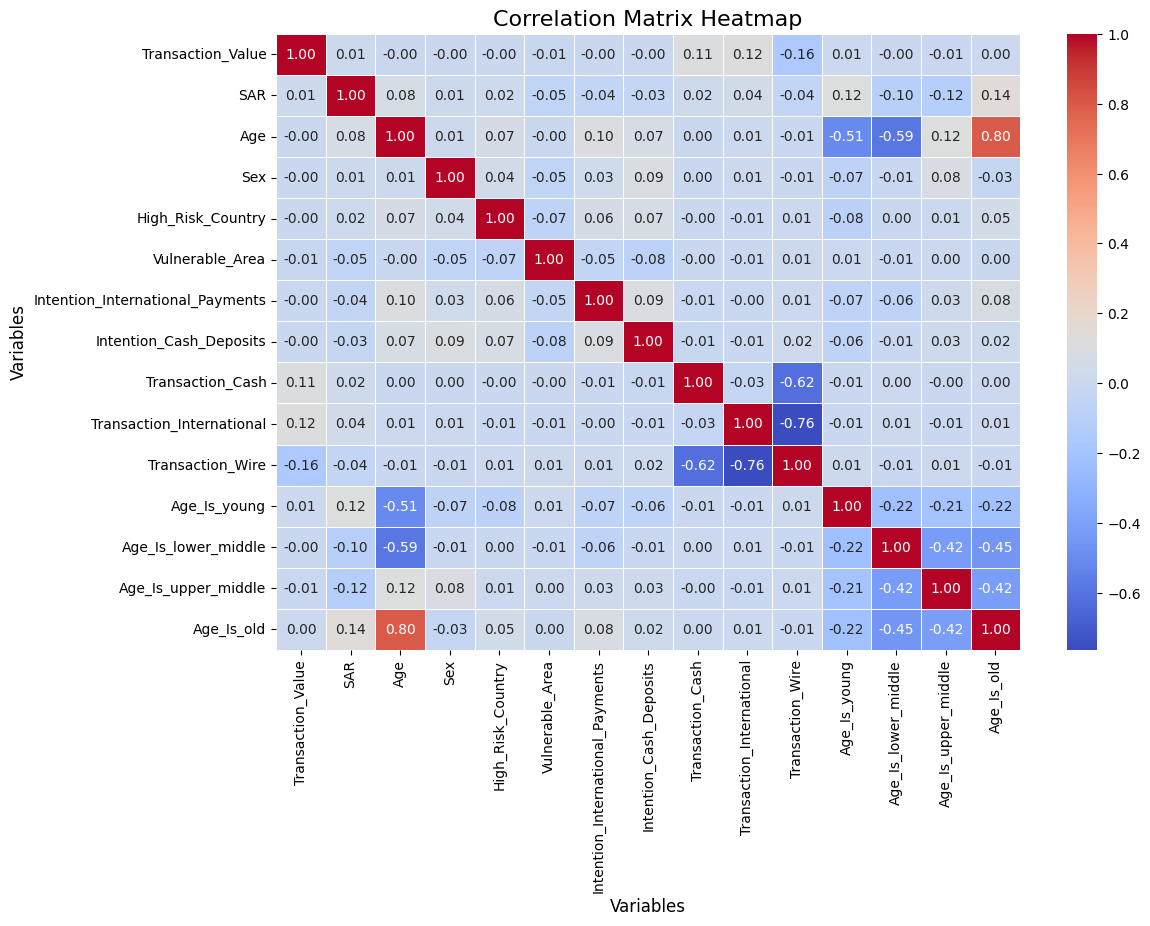

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame with the correlation matrix is named `correlation_df`
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(trusted_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Add title and labels
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Variables", fontsize=12)

# Display the heatmap
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (SVM is sensitive to scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM classifier
svm_classifier = SVC(kernel='rbf', probability=True, random_state=42)

# Train the SVM model
svm_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_classifier.predict(X_test_scaled)
y_pred_proba = svm_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.81
ROC-AUC Score: 0.67
Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      6303
           1       0.61      0.01      0.02      1453

    accuracy                           0.81      7756
   macro avg       0.71      0.50      0.46      7756
weighted avg       0.78      0.81      0.73      7756



### Training the Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Define features and target variable
X = trusted_data.drop(columns=['SAR'])  # Features
y = trusted_data['SAR']  # Target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale only numeric features (excluding binary or one-hot encoded ones)
scaled_features = scaler.fit_transform(X)

# Convert back to DataFrame for clarity (optional)
X_scaled = pd.DataFrame(scaled_features, columns=X.columns)

In [ ]:
X_scaled.head()

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Assuming you have your features (X) and labels (y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("Class distribution:", y_train.value_counts())

print("After SMOTE:")
print("Class distribution:", y_train_resampled.value_counts())


Before SMOTE:
Class distribution: SAR
0    25258
1     5762
Name: count, dtype: int64
After SMOTE:
Class distribution: SAR
0    25258
1    25258
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("Classification Report:")
print(classification_rep)


Accuracy: 0.73
ROC-AUC Score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      6254
           1       0.36      0.46      0.40      1502

    accuracy                           0.73      7756
   macro avg       0.61      0.63      0.62      7756
weighted avg       0.76      0.73      0.75      7756



/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:25:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      6254
           1       0.39      0.48      0.43      1502

    accuracy                           0.76      7756
   macro avg       0.63      0.65      0.64      7756
weighted avg       0.78      0.76      0.77      7756

ROC-AUC Score: 0.75


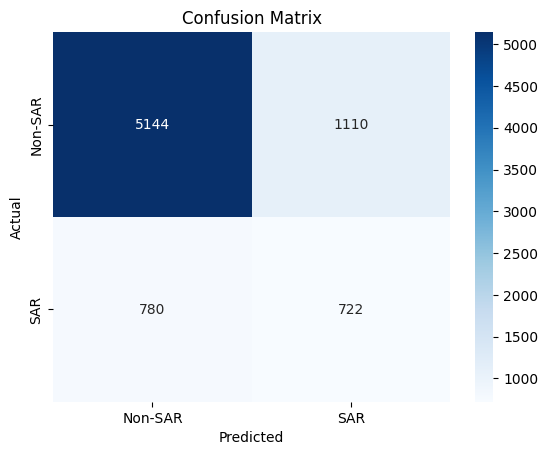

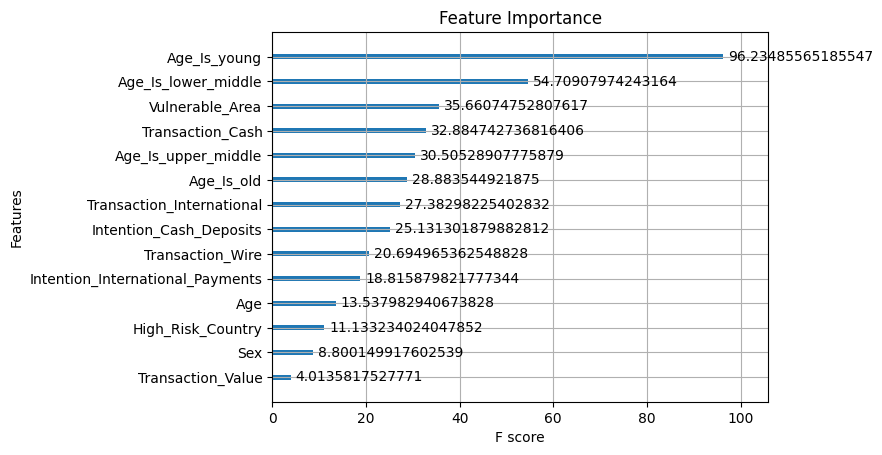

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Instantiate the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # Binary classification
    eval_metric='auc',           # Use AUC as the evaluation metric
    scale_pos_weight=len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1]),  # Handle class imbalance
    use_label_encoder=False,     # Suppress label encoder warning
    random_state=42
)

# Train the model
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-SAR', 'SAR'], yticklabels=['Non-SAR', 'SAR'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
xgb.plot_importance(xgb_model, importance_type="gain")
plt.title("Feature Importance")
plt.show()


In [ ]:
untrusted_data.head()

,Customer_ID,Customer_ID_Counterparty,Transaction_Value,Transaction_Type,Month,SAR,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
1,758,NaN,13,Wire,Jan,0,67,Female,True,False,True,False
2,485,NaN,25,Wire,Jan,0,78,Male,False,False,True,True
3,238,NaN,-456,Wire,Jan,0,55,Female,False,False,False,False
4,858,NaN,-4,Wire,Jan,0,77,Female,False,False,False,False
6,888,NaN,-148,Wire,Jan,0,18,Female,True,False,True,False


In [ ]:
untrusted_data = untrusted_data.drop(columns=['SAR', 'Customer_ID', 'Customer_ID_Counterparty'])
untrusted_data.head()

,Transaction_Value,Transaction_Type,Month,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
1,13,Wire,Jan,67,Female,True,False,True,False
2,25,Wire,Jan,78,Male,False,False,True,True
3,-456,Wire,Jan,55,Female,False,False,False,False
4,-4,Wire,Jan,77,Female,False,False,False,False
6,-148,Wire,Jan,18,Female,True,False,True,False


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

# Assuming 'data' is your original DataFrame
# Replace 'data' with your dataset variable

# Step 1: Select numerical, categorical, and boolean features
numerical_columns = ['Transaction_Value', 'Age']
categorical_columns = ['Transaction_Type', 'Month', 'Sex']
boolean_columns = ['High_Risk_Country', 'Vulnerable_Area', 'Intention_International_Payments', 'Intention_Cash_Deposits']

# Step 2: Standardize numerical features
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(untrusted_data[numerical_columns])

# Step 3: One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, drop='first')  # 'drop="first"' to avoid multicollinearity
encoded_categorical = encoder.fit_transform(untrusted_data[categorical_columns])

# Step 4: Combine processed features into a single DataFrame
processed_data = pd.concat(
    [
        pd.DataFrame(scaled_numerical, columns=numerical_columns),  # Numerical features
        pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns)),  # Categorical features
        untrusted_data[boolean_columns].reset_index(drop=True)  # Boolean features
    ],
    axis=1
)

# Display the first few rows of the processed data
print(processed_data.head())


   Transaction_Value       Age  Transaction_Type_International  \
0           0.631692  0.780746                             0.0   
1           0.652834  1.325103                             0.0   
2          -0.194579  0.186902                             0.0   
3           0.601742  1.275616                             0.0   
4           0.348047 -1.644117                             0.0   

   Transaction_Type_Wire  Month_Aug  Month_Dec  Month_Feb  Month_Jan  \
0                    1.0        0.0        0.0        0.0        1.0   
1                    1.0        0.0        0.0        0.0        1.0   
2                    1.0        0.0        0.0        0.0        1.0   
3                    1.0        0.0        0.0        0.0        1.0   
4                    1.0        0.0        0.0        0.0        1.0   

   Month_Jul  Month_Jun  Month_Mar  Month_May  Month_Nov  Month_Oct  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0     

In [ ]:
from sklearn.ensemble import IsolationForest

# Step 1: Preprocessing the Data (ensure your data is numeric and scaled as required)
# Assuming 'processed_data' is your preprocessed dataset without the target column
# Replace 'processed_data' with your dataset variable

# Step 2: Initialize the Isolation Forest model
iso_forest = IsolationForest(
    n_estimators=100,          # Number of trees in the forest
    contamination=0.05,        # Proportion of anomalies in the data
    random_state=42            # For reproducibility
)

# Step 3: Fit the model and predict anomalies
anomaly_scores = iso_forest.fit_predict(processed_data)

# Step 4: Add the anomaly scores to the dataset
processed_data['Anomaly_Score'] = anomaly_scores

# Step 5: Analyze anomalies
# -1 indicates an anomaly, 1 indicates normal behavior
anomaly_count = (anomaly_scores == -1).sum()
print(f"Number of anomalies detected: {anomaly_count}")

# Optional: View anomalies
anomalies = processed_data[processed_data['Anomaly_Score'] == -1]
print(anomalies.head())

# Step 6: Save anomalies to a file (optional)
anomalies.to_csv("anomalies_detected.csv", index=False)


Number of anomalies detected: 5862
    Transaction_Value       Age  Transaction_Type_International  \
27          -2.668108  1.374590                             1.0   
48           2.793388  1.275616                             0.0   
65          -0.006069  0.038441                             0.0   
71          -2.580019  0.137415                             1.0   
73          -2.544784  1.028181                             0.0   

    Transaction_Type_Wire  Month_Aug  Month_Dec  Month_Feb  Month_Jan  \
27                    0.0        0.0        0.0        0.0        1.0   
48                    0.0        0.0        0.0        0.0        1.0   
65                    1.0        0.0        0.0        0.0        1.0   
71                    0.0        0.0        0.0        0.0        1.0   
73                    1.0        0.0        0.0        0.0        1.0   

    Month_Jul  Month_Jun  ...  Month_May  Month_Nov  Month_Oct  Month_Sep  \
27        0.0        0.0  ...        0.0      

In [ ]:
processed_data['Anomaly_Score'].value_counts()

,count
Anomaly_Score,
1,111508
-1,5862
